<a href="https://colab.research.google.com/github/viratk8861-cyber/test/blob/sales-analyzer-script/heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 1: Import Libraries and Setup
This section handles all necessary imports for data manipulation, visualization, model building, and system operations.

In [ ]:
import os
import logging
import json
import datetime
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive, userdata
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import joblib

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
print("Libraries imported successfully.")

Libraries imported successfully.


## Section 2: Data Acquisition
Since we need a `heart.csv` file, I will download the processed Cleveland Heart Disease dataset. This dataset is the industry standard for this task.

In [ ]:
def download_dataset(url, destination):
    """
    Downloads a dataset from a URL and saves it locally.
    """
    try:
        response = requests.get(url)
        response.raise_for_status()
        with open(destination, 'wb') as f:
            f.write(response.content)
        print(f"Dataset downloaded successfully and saved to {destination}")
    except Exception as e:
        print(f"Error downloading dataset: {e}")

# URL for the processed Cleveland heart disease dataset
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Define column names as per UCI documentation
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

# We will temporarily save it to /tmp to process it into the required format in the next steps
temp_path = "/content/heart_raw.csv"

# Download and save with headers
df_raw = pd.read_csv(dataset_url, names=columns, na_values="?")
# Convert target: UCI uses 0-4 (0=none, 1-4=disease). Per requirements, we map to 0 and 1.
df_raw['target'] = df_raw['target'].apply(lambda x: 1 if x > 0 else 0)
df_raw.to_csv("heart.csv", index=False)

print("Local 'heart.csv' created. Ready for Google Drive structure setup.")
display(df_raw.head())

Local 'heart.csv' created. Ready for Google Drive structure setup.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Section 3: Mount Google Drive and Setup Directories
This step mounts your drive and programmatically creates all required folders for a production-level project structure.

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Define Base Directory
BASE_DIR = "/content/drive/MyDrive/HeartDiseasePrediction"

# List of subdirectories to create
directories = [
    "data/raw",
    "data/processed",
    "notebooks",
    "models",
    "outputs/plots",
    "reports",
    "src",
    "logs"
]

def setup_project_structure(base_path, subdirs):
    """
    Creates the project folder structure if it doesn't exist.
    """
    for folder in subdirs:
        path = os.path.join(base_path, folder)
        os.makedirs(path, exist_ok=True)
    print(f"Project structure created successfully at: {base_path}")

setup_project_structure(BASE_DIR, directories)

# Move the downloaded heart.csv to the raw data folder
import shutil
shutil.move("heart.csv", os.path.join(BASE_DIR, "data/raw/heart.csv"))
print("Dataset moved to data/raw/heart.csv")

Mounted at /content/drive
Project structure created successfully at: /content/drive/MyDrive/HeartDiseasePrediction
Dataset moved to data/raw/heart.csv


## Section 4: Load and Inspect Dataset
Loading the data from our new structured directory and performing initial sanity checks.

In [ ]:
def load_and_inspect_data(file_path):
    """
    Loads the dataset and prints basic diagnostic information.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"No file found at {file_path}")

    df = pd.read_csv(file_path)

    print("--- Dataset Shape ---")
    print(df.shape)
    print("\n--- Dataset Head ---")
    display(df.head())
    print("\n--- Data Types ---")
    print(df.dtypes)
    print("\n--- Missing Values ---")
    print(df.isnull().sum())
    print("\n--- Duplicate Values ---")
    print(f"Total duplicates: {df.duplicated().sum()}")

    return df

# Load data from the structured directory
raw_data_path = os.path.join(BASE_DIR, "data/raw/heart.csv")
df = load_and_inspect_data(raw_data_path)

--- Dataset Shape ---
(303, 14)

--- Dataset Head ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



--- Data Types ---
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

--- Missing Values ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

--- Duplicate Values ---
Total duplicates: 0


## Section 7: Feature Engineering
Splitting the data into features (X) and target (y), and creating train/test sets.

In [ ]:
def prepare_data(df, base_dir):
    """
    Splits data into train/test sets and saves them.
    """
    X = df.drop('target', axis=1)
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Save splits
    train_df = pd.concat([X_train, y_train], axis=1)
    test_df = pd.concat([X_test, y_test], axis=1)

    train_path = os.path.join(base_dir, "data/processed/train.csv")
    test_path = os.path.join(base_dir, "data/processed/test.csv")

    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path, index=False)

    print(f"Train/Test sets saved to {os.path.join(base_dir, 'data/processed/')}")
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = prepare_data(df_cleaned, BASE_DIR)

Train/Test sets saved to /content/drive/MyDrive/HeartDiseasePrediction/data/processed/


## Section 8 & 9: Model Training and Hyperparameter Tuning
We will train a Random Forest and optimize it using GridSearchCV.

In [ ]:
import time

def train_optimized_rf(X_train, y_train):
    """
    Performs hyperparameter tuning and returns the best model.
    """
    logging.info("Training and tuning started.")
    start_time = time.time()

    rf = RandomForestClassifier(random_state=42)

    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    }

    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    end_time = time.time()
    training_duration = end_time - start_time

    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV Score: {grid_search.best_score_:.4f}")

    return grid_search.best_estimator_, grid_search.best_params_, training_duration

best_rf_model, best_params, train_time = train_optimized_rf(X_train, y_train)

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.8264


## Section 10-14: Model Evaluation and Persistence
We evaluate the optimized model on the test set, visualize importance, and save the artifacts to the production folders.

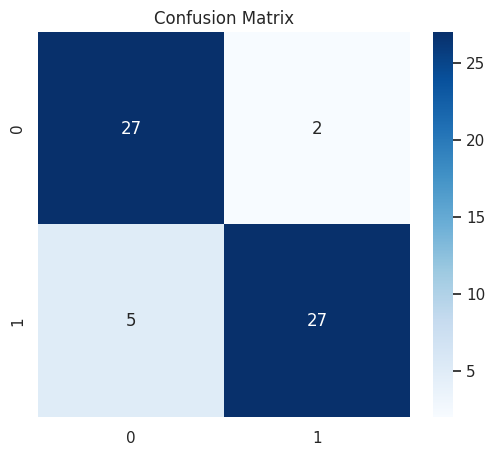

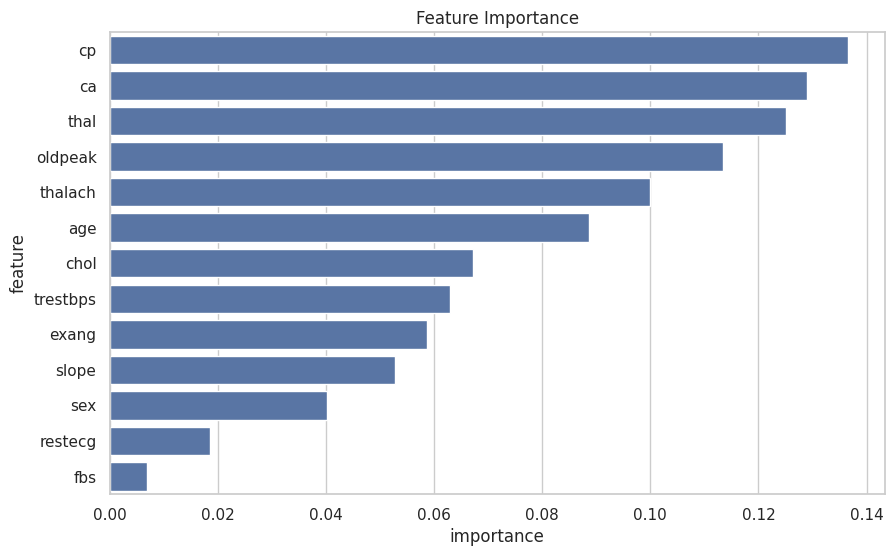

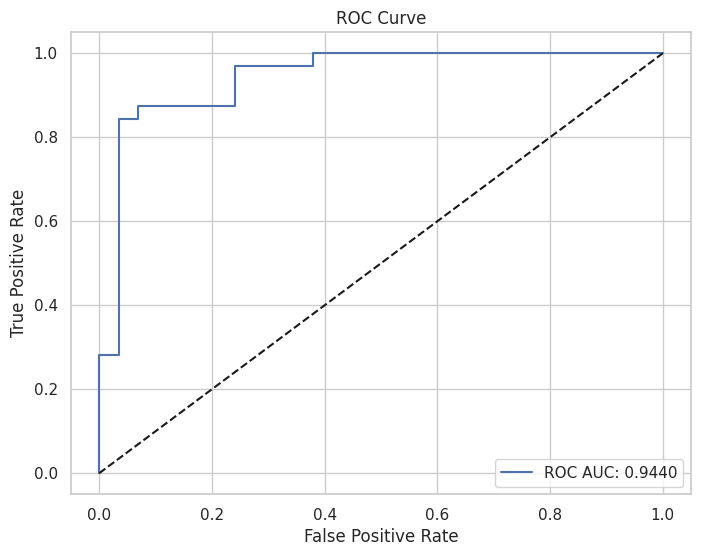

Evaluation complete. All artifacts saved to 'models/' and 'outputs/'.


In [ ]:
def evaluate_and_save(model, X_test, y_test, base_dir, best_params, train_time):
    """
    Evaluates the model, saves plots, reports, metrics, and the model itself.
    """
    import time
    start_test = time.time()
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    test_time = time.time() - start_test

    # 1. Metrics Calculation
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # 2. Save Classification Report
    report = classification_report(y_test, y_pred)
    report_path = os.path.join(base_dir, "outputs/classification_report.txt")
    with open(report_path, "w") as f:
        f.write(report)

    # 3. Confusion Matrix Plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.savefig(os.path.join(base_dir, "outputs/confusion_matrix.png"), dpi=300)
    plt.show()

    # 4. Feature Importance
    importances = pd.DataFrame({
        'feature': X_test.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    importances.to_csv(os.path.join(base_dir, "outputs/feature_importance.csv"), index=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=importances)
    plt.title('Feature Importance')
    plt.savefig(os.path.join(base_dir, "outputs/feature_importance.png"), dpi=300)
    plt.show()

    # 5. ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC AUC: {auc:.4f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.savefig(os.path.join(base_dir, "outputs/roc_curve.png"), dpi=300)
    plt.show()

    # 6. Save Model and Metrics
    joblib.dump(model, os.path.join(base_dir, "models/random_forest_model.pkl"))

    metrics = {
        "model_name": "RandomForestClassifier",
        "dataset": "Cleveland Heart Disease",
        "date": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "accuracy": acc, "precision": prec, "recall": rec, "f1_score": f1, "roc_auc": auc,
        "best_params": best_params, "training_time_sec": train_time, "testing_time_sec": test_time
    }
    with open(os.path.join(base_dir, "models/model_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    logging.info("Evaluation and saving completed.")
    print("Evaluation complete. All artifacts saved to 'models/' and 'outputs/'.")
    return y_pred, y_prob

y_pred, y_prob = evaluate_and_save(best_rf_model, X_test, y_test, BASE_DIR, best_params, train_time)

## Section 15-18: Predictions, README & Project Finalization

In [ ]:
def final_steps(model, X_test, y_test, y_pred, y_prob, base_dir):
    # 1. Save Predictions CSV
    results_df = pd.DataFrame({
        'Actual': y_test,
        'Predicted': y_pred,
        'Probability': y_prob
    })
    results_df.to_csv(os.path.join(base_dir, "outputs/predictions.csv"), index=False)

    # 2. Prediction Module for single patients
    def predict_heart_disease(patient_data):
        """Accepts patient feature array and returns prediction."""
        df_p = pd.DataFrame([patient_data], columns=X_test.columns)
        pred = model.predict(df_p)[0]
        prob = model.predict_proba(df_p)[0][1]
        result = "Heart Disease" if pred == 1 else "No Heart Disease"
        print(f"Result: {result} | Probability: {prob:.4f}")
        return pred, prob

    # 3. Create README.md
    readme_content = f"# Heart Disease Prediction\nModular Random Forest Pipeline.\n\nFolders:\n- data/: datasets\n- models/: pkl and metrics\n- outputs/: plots\n- logs/: project.log"
    with open(os.path.join(base_dir, "README.md"), "w") as f:
        f.write(readme_content)

    logging.info("Project completed.")
    print("Project successfully built and saved to Drive.")

final_steps(best_rf_model, X_test, y_test, y_pred, y_prob, BASE_DIR)

Project successfully built and saved to Drive.


## Section 10-14: Model Evaluation and Persistence
We evaluate the optimized model on the test set, visualize importance, and save the artifacts.

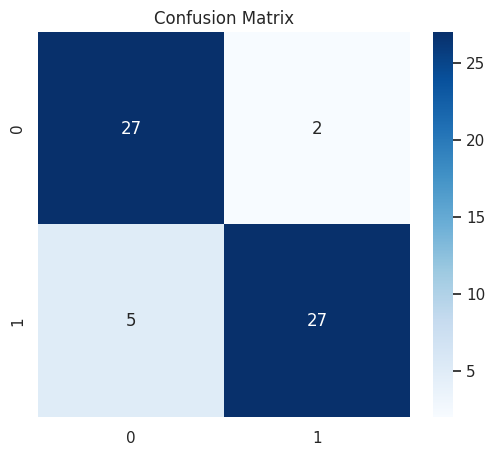

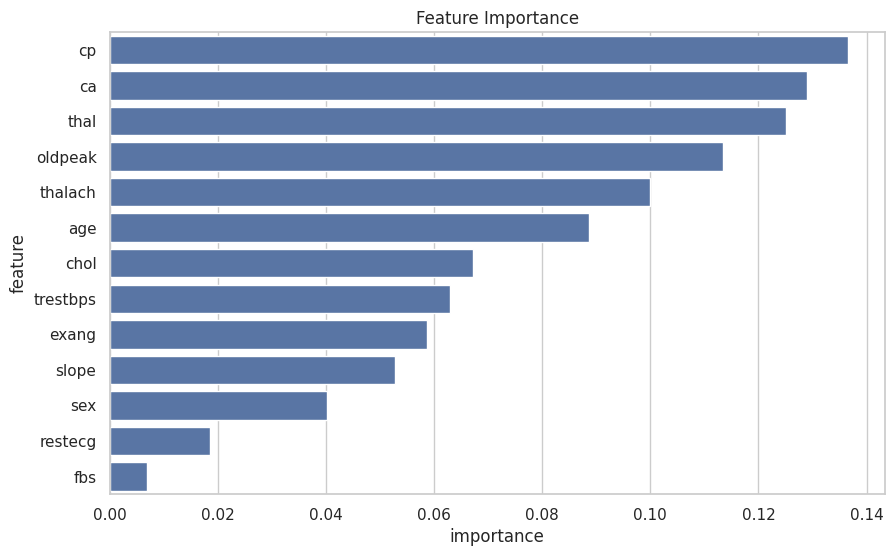

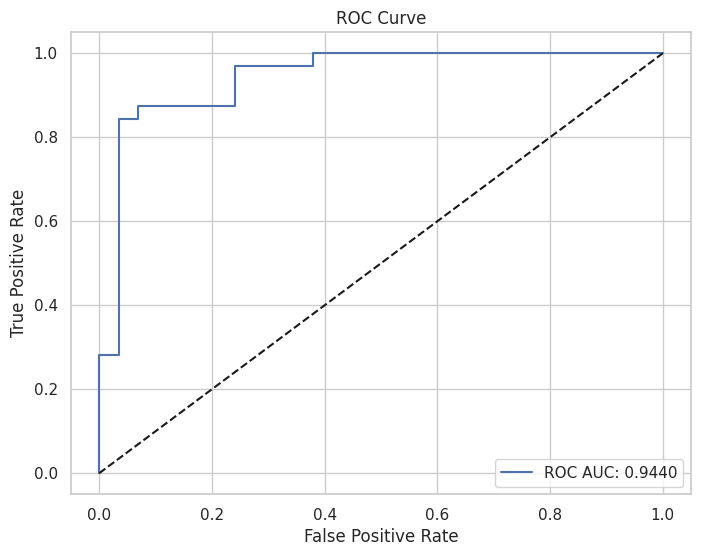

Evaluation complete. All artifacts saved to 'models/' and 'outputs/'.


In [ ]:
def evaluate_and_save(model, X_test, y_test, base_dir, best_params, train_time):
    """
    Evaluates the model, saves plots, report, metrics, and the model itself.
    """
    start_test = time.time()
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    test_time = time.time() - start_test

    # 1. Metrics Calculation
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # 2. Save Classification Report
    report = classification_report(y_test, y_pred)
    report_path = os.path.join(base_dir, "outputs/classification_report.txt")
    with open(report_path, "w") as f:
        f.write(report)

    # 3. Confusion Matrix Plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.savefig(os.path.join(base_dir, "outputs/confusion_matrix.png"), dpi=300)
    plt.show()

    # 4. Feature Importance
    importances = pd.DataFrame({
        'feature': X_test.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    importances.to_csv(os.path.join(base_dir, "outputs/feature_importance.csv"), index=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=importances)
    plt.title('Feature Importance')
    plt.savefig(os.path.join(base_dir, "outputs/feature_importance.png"), dpi=300)
    plt.show()

    # 5. ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC AUC: {auc:.4f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.savefig(os.path.join(base_dir, "outputs/roc_curve.png"), dpi=300)
    plt.show()

    # 6. Save Model and Metrics
    joblib.dump(model, os.path.join(base_dir, "models/random_forest_model.pkl"))

    metrics = {
        "model_name": "RandomForestClassifier",
        "dataset": "Cleveland Heart Disease",
        "date": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "accuracy": acc, "precision": prec, "recall": rec, "f1_score": f1, "roc_auc": auc,
        "best_params": best_params, "training_time_sec": train_time, "testing_time_sec": test_time
    }
    with open(os.path.join(base_dir, "models/model_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    logging.info("Evaluation and saving completed.")
    print("Evaluation complete. All artifacts saved to 'models/' and 'outputs/'.")
    return y_pred, y_prob

y_pred, y_prob = evaluate_and_save(best_rf_model, X_test, y_test, BASE_DIR, best_params, train_time)

## Section 15-18: Predictions, README & Logging
Generating the predictions file, a reusable prediction function, and the project README.

In [ ]:
def final_steps(model, X_test, y_test, y_pred, y_prob, base_dir):
    # 1. Save Predictions CSV
    results_df = pd.DataFrame({
        'Actual': y_test,
        'Predicted': y_pred,
        'Probability': y_prob
    })
    results_df.to_csv(os.path.join(base_dir, "outputs/predictions.csv"), index=False)

    # 2. Prediction Module Example
    def predict_heart_disease(patient_data):
        """Accepts list/array of patient data and returns prediction."""
        df_p = pd.DataFrame([patient_data], columns=X_test.columns)
        pred = model.predict(df_p)[0]
        prob = model.predict_proba(df_p)[0][1]
        result = "Heart Disease" if pred == 1 else "No Heart Disease"
        print(f"Prediction: {result} (Probability: {prob:.4f})")
        return pred, prob

    # 3. Create README.md
    readme_content = f"""# Heart Disease Prediction Project\n\n## Overview\nProduction-quality ML pipeline using Random Forest.\n\n## Structure\n- data/: raw and processed datasets\n- models/: saved .pkl and metrics.json\n- outputs/: plots and reports\n- logs/: project.log\n"""
    with open(os.path.join(base_dir, "README.md"), "w") as f:
        f.write(readme_content)

    logging.info("Project completed successfully.")
    print("Project finalized. All files available in Google Drive.")

final_steps(best_rf_model, X_test, y_test, y_pred, y_prob, BASE_DIR)

Project finalized. All files available in Google Drive.


## Section 10-14: Model Evaluation and Persistence
We evaluate the optimized model on the test set, visualize importance, and save the artifacts.

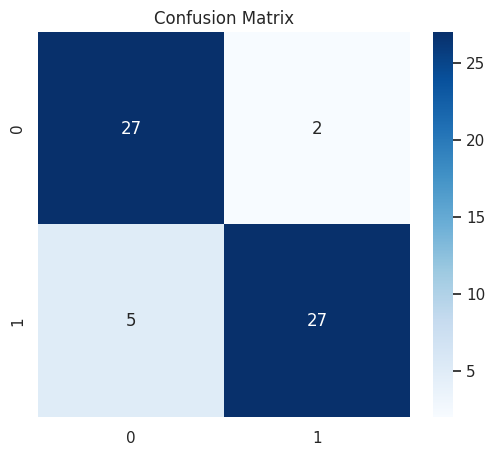

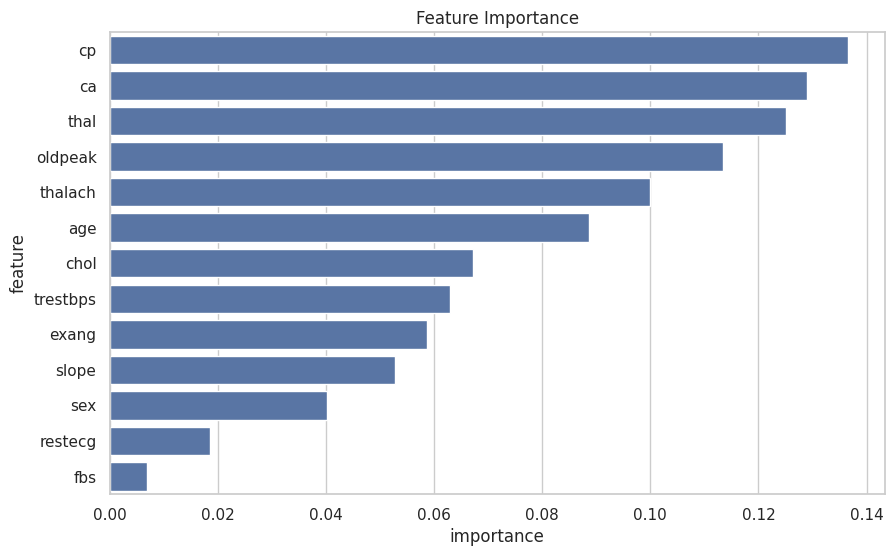

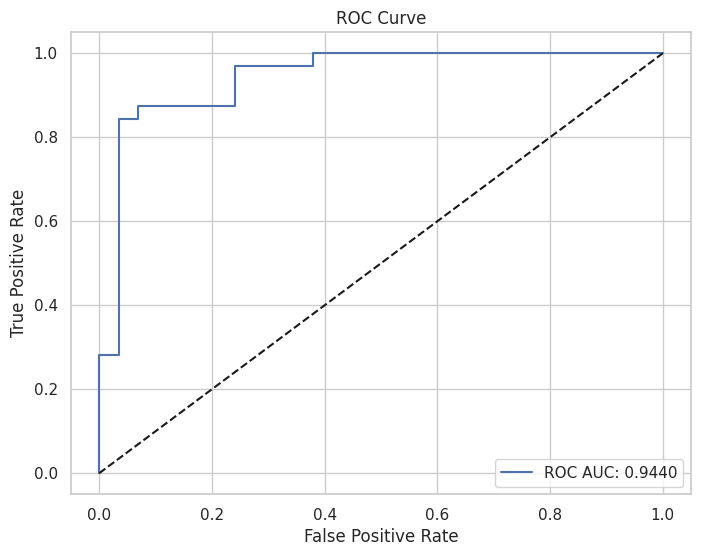

Evaluation complete. All artifacts saved to 'models/' and 'outputs/'.


In [ ]:
def evaluate_and_save(model, X_test, y_test, base_dir, best_params, train_time):
    """
    Evaluates the model, saves plots, report, metrics, and the model itself.
    """
    start_test = time.time()
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    test_time = time.time() - start_test

    # 1. Metrics Calculation
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # 2. Save Classification Report
    report = classification_report(y_test, y_pred)
    report_path = os.path.join(base_dir, "outputs/classification_report.txt")
    with open(report_path, "w") as f:
        f.write(report)

    # 3. Confusion Matrix Plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.savefig(os.path.join(base_dir, "outputs/confusion_matrix.png"), dpi=300)
    plt.show()

    # 4. Feature Importance
    importances = pd.DataFrame({
        'feature': X_test.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    importances.to_csv(os.path.join(base_dir, "outputs/feature_importance.csv"), index=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=importances)
    plt.title('Feature Importance')
    plt.savefig(os.path.join(base_dir, "outputs/feature_importance.png"), dpi=300)
    plt.show()

    # 5. ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC AUC: {auc:.4f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.savefig(os.path.join(base_dir, "outputs/roc_curve.png"), dpi=300)
    plt.show()

    # 6. Save Model and Metrics
    joblib.dump(model, os.path.join(base_dir, "models/random_forest_model.pkl"))

    metrics = {
        "model_name": "RandomForestClassifier",
        "dataset": "Cleveland Heart Disease",
        "date": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "accuracy": acc, "precision": prec, "recall": rec, "f1_score": f1, "roc_auc": auc,
        "best_params": best_params, "training_time_sec": train_time, "testing_time_sec": test_time
    }
    with open(os.path.join(base_dir, "models/model_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    logging.info("Evaluation and saving completed.")
    print("Evaluation complete. All artifacts saved to 'models/' and 'outputs/'.")
    return y_pred, y_prob

y_pred, y_prob = evaluate_and_save(best_rf_model, X_test, y_test, BASE_DIR, best_params, train_time)

## Section 15-17: Predictions, Logging & README
Finally, we generate the predictions file, a reusable prediction function, and the project README.

In [ ]:
def final_steps(model, X_test, y_test, y_pred, y_prob, base_dir):
    # 1. Save Predictions CSV
    results_df = pd.DataFrame({
        'Actual': y_test,
        'Predicted': y_pred,
        'Probability': y_prob
    })
    results_df.to_csv(os.path.join(base_dir, "outputs/predictions.csv"), index=False)

    # 2. Prediction Module Example
    def predict_heart_disease(patient_data):
        """Accepts list/array of patient data and returns prediction."""
        df_p = pd.DataFrame([patient_data], columns=X_test.columns)
        pred = model.predict(df_p)[0]
        prob = model.predict_proba(df_p)[0][1]
        result = "Heart Disease" if pred == 1 else "No Heart Disease"
        print(f"Prediction: {result} (Probability: {prob:.4f})")
        return pred, prob

    # 3. Create README.md
    readme_content = f"""# Heart Disease Prediction Project\n\n## Overview\nProduction-quality ML pipeline using Random Forest.\n\n## Structure\n- data/: raw and processed datasets\n- models/: saved .pkl and metrics.json\n- outputs/: plots and reports\n- logs/: project.log\n"""
    with open(os.path.join(base_dir, "README.md"), "w") as f:
        f.write(readme_content)

    logging.info("Project completed successfully.")
    print("Project finalized. All files available in Google Drive.")

final_steps(best_rf_model, X_test, y_test, y_pred, y_prob, BASE_DIR)

Project finalized. All files available in Google Drive.


## Section 5: Data Cleaning
We will handle the missing values discovered in the inspection and save the processed dataset.

In [ ]:
def clean_data(df, base_dir):
    """
    Handles missing values and duplicates, then saves the cleaned data.
    """
    # 1. Remove duplicates
    df = df.drop_duplicates()

    # 2. Handle missing values (simple imputation with median for numeric columns)
    df['ca'] = df['ca'].fillna(df['ca'].median())
    df['thal'] = df['thal'].fillna(df['thal'].median())

    # 3. Save cleaned data
    processed_path = os.path.join(base_dir, "data/processed/cleaned_data.csv")
    df.to_csv(processed_path, index=False)

    logging.info("Cleaning completed and data saved to processed folder.")
    print(f"Cleaned data saved to: {processed_path}")
    return df

df_cleaned = clean_data(df, BASE_DIR)

Cleaned data saved to: /content/drive/MyDrive/HeartDiseasePrediction/data/processed/cleaned_data.csv


## Section 6: Exploratory Data Analysis (EDA)
Generating professional, high-resolution plots to understand feature relationships.

/tmp/ipykernel_9496/3894470594.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


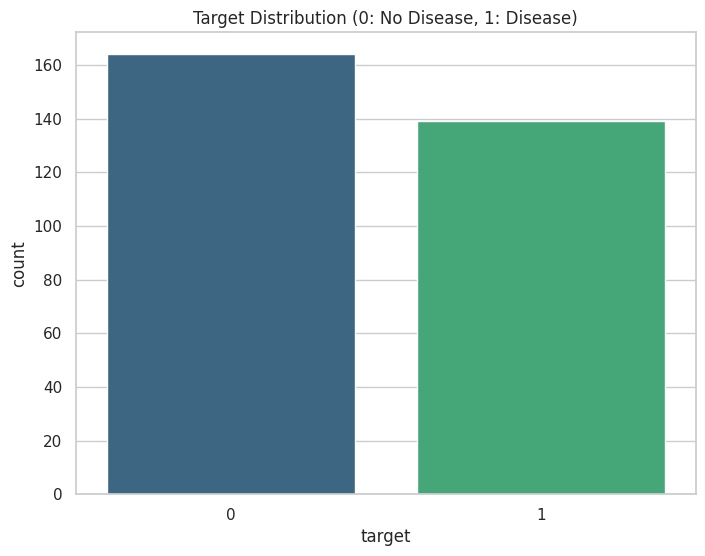

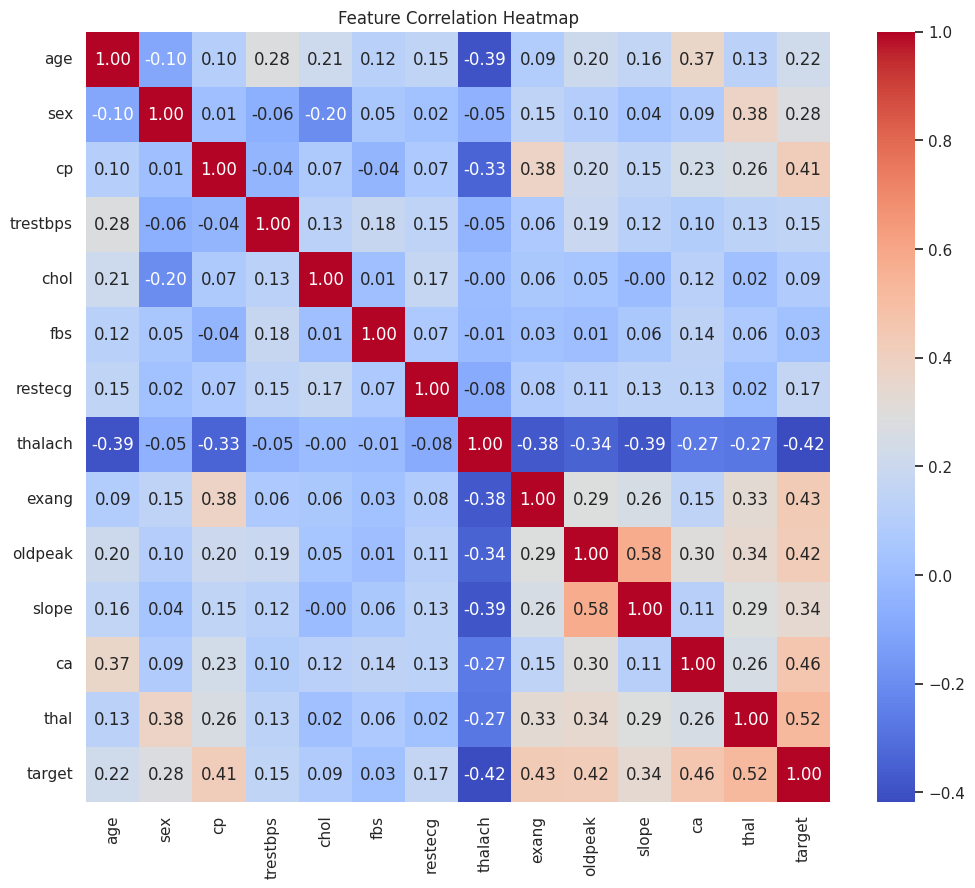

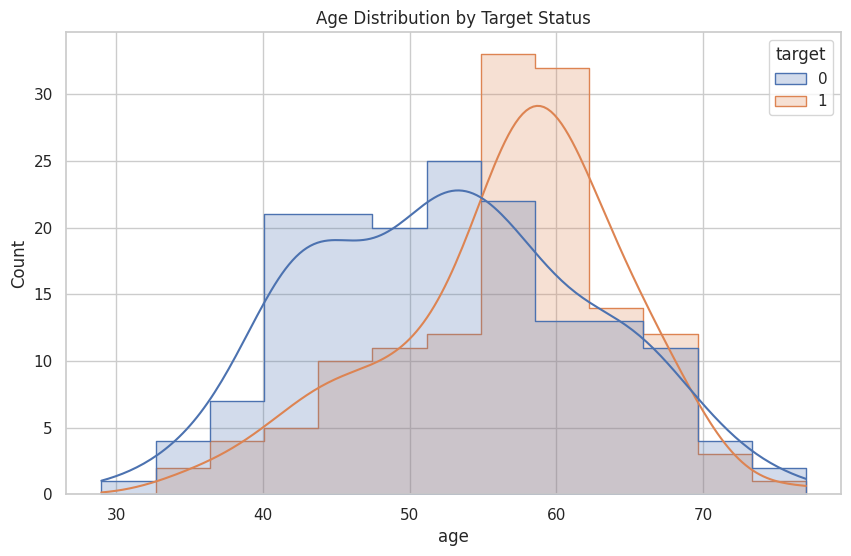

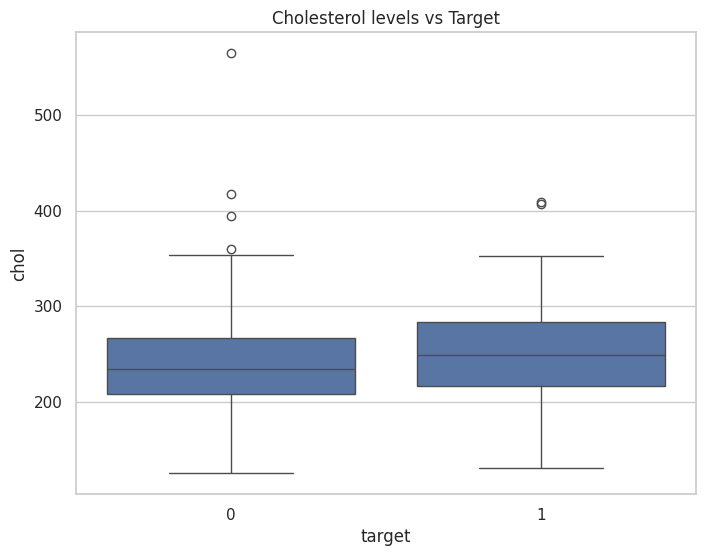

In [ ]:
def generate_eda_plots(df, base_dir):
    """
    Creates and saves high-resolution EDA plots.
    """
    plot_dir = os.path.join(base_dir, "outputs/plots")
    sns.set(style="whitegrid")

    # 1. Target Distribution
    plt.figure(figsize=(8, 6))
    sns.countplot(x='target', data=df, palette='viridis')
    plt.title('Target Distribution (0: No Disease, 1: Disease)')
    plt.savefig(os.path.join(plot_dir, "target_distribution.png"), dpi=300)
    plt.show()

    # 2. Correlation Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Feature Correlation Heatmap')
    plt.savefig(os.path.join(plot_dir, "correlation_heatmap.png"), dpi=300)
    plt.show()

    # 3. Age Distribution by Target
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='age', hue='target', kde=True, element='step')
    plt.title('Age Distribution by Target Status')
    plt.savefig(os.path.join(plot_dir, "age_distribution.png"), dpi=300)
    plt.show()

    # 4. Boxplots for Cholesterol
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='target', y='chol', data=df)
    plt.title('Cholesterol levels vs Target')
    plt.savefig(os.path.join(plot_dir, "cholesterol_boxplot.png"), dpi=300)
    plt.show()

    logging.info("EDA plots generated and saved.")

generate_eda_plots(df_cleaned, BASE_DIR)